In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
raw_url = "https://raw.githubusercontent.com/KhaledMahaMudRajon/Assignment_DT-K-Means-Clustering/refs/heads/main/drug200.csv"
df = pd.read_csv(raw_url)
print("Data loaded successfully. Shape:", df.shape)
df.head()

Data loaded successfully. Shape: (200, 6)


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
categorical_cols = ['Sex', 'BP', 'Cholesterol']
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [4]:
X = df.drop('Drug', axis=1)
y = df['Drug']

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
target_names = le_target.classes_

print("Feature columns:", X.columns.tolist())
print("Target classes:", target_names)

Feature columns: ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
Target classes: ['drugA' 'drugB' 'drugC' 'drugX' 'drugY']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [6]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cart_base = DecisionTreeClassifier(criterion='gini', random_state=42)
grid_cart = GridSearchCV(cart_base, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_cart.fit(X_train, y_train)
best_cart = grid_cart.best_estimator_
print(f"Best CART params: {grid_cart.best_params_}, CV accuracy: {grid_cart.best_score_:.4f}")

Best CART params: {'max_depth': 5, 'min_samples_split': 2}, CV accuracy: 1.0000


In [7]:
id3_base = DecisionTreeClassifier(criterion='entropy', random_state=42)
grid_id3 = GridSearchCV(id3_base, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_id3.fit(X_train, y_train)
best_id3 = grid_id3.best_estimator_
print(f"Best ID3 params: {grid_id3.best_params_}, CV accuracy: {grid_id3.best_score_:.4f}")

Best ID3 params: {'max_depth': 5, 'min_samples_split': 2}, CV accuracy: 1.0000


In [8]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'AUC': auc}

metrics_cart = evaluate_model(best_cart, X_test, y_test, 'CART (Gini)')
metrics_id3 = evaluate_model(best_id3, X_test, y_test, 'ID3 (Entropy)')
metrics_df = pd.DataFrame([metrics_cart, metrics_id3])
print("\nTest Set Metrics:\n", metrics_df)



Test Set Metrics:
            Model  Accuracy  Precision    Recall        F1      AUC
0    CART (Gini)     0.975   0.966667  0.933333  0.941818  0.96381
1  ID3 (Entropy)     0.975   0.966667  0.933333  0.941818  0.96381


In [9]:
plt.rcParams['figure.figsize'] = (12, 5)

# ----- 6.1 Decision Boundary (using PCA to 2D) -----
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

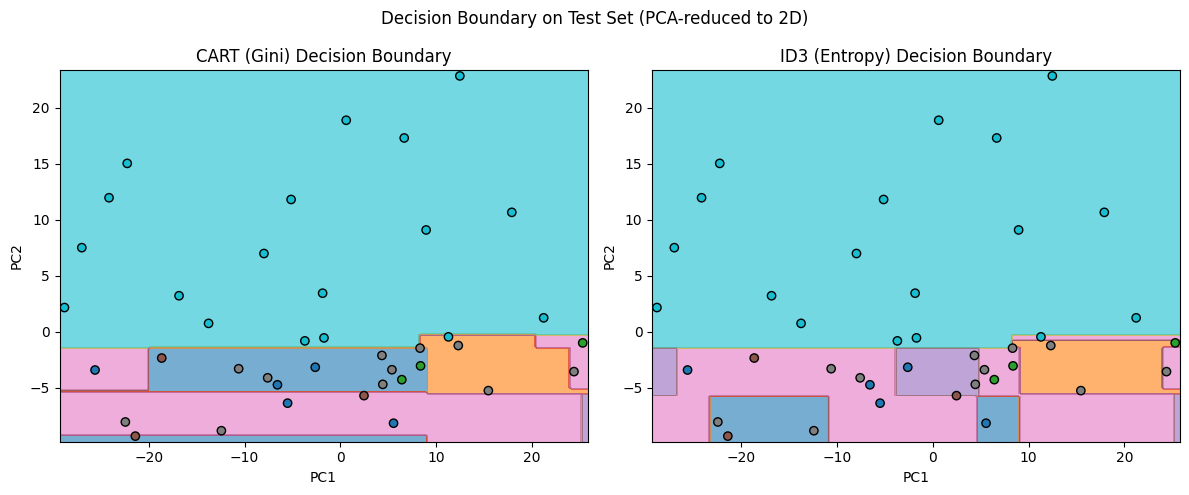

In [10]:
cart_pca = DecisionTreeClassifier(criterion='gini', **grid_cart.best_params_, random_state=42)
cart_pca.fit(X_train_pca, y_train)
id3_pca = DecisionTreeClassifier(criterion='entropy', **grid_id3.best_params_, random_state=42)
id3_pca.fit(X_train_pca, y_train)

def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.6, cmap='tab10')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    return scatter

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(cart_pca, X_test_pca, y_test, axes[0], "CART (Gini) Decision Boundary")
plot_decision_boundary(id3_pca, X_test_pca, y_test, axes[1], "ID3 (Entropy) Decision Boundary")
plt.suptitle("Decision Boundary on Test Set (PCA-reduced to 2D)")
plt.tight_layout()
plt.show()

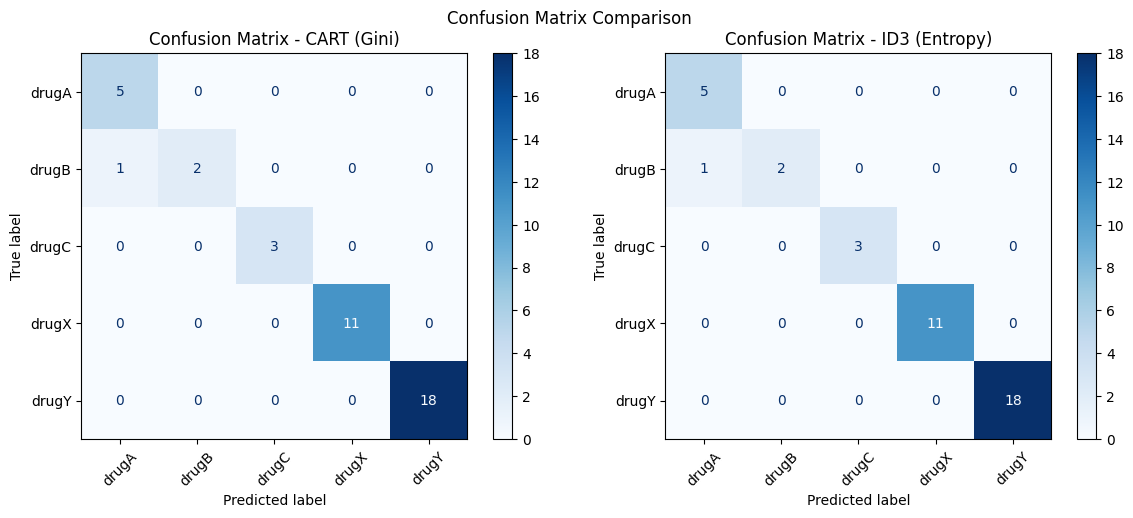

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, name in zip(axes, [best_cart, best_id3], ['CART (Gini)', 'ID3 (Entropy)']):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
    ax.set_title(f'Confusion Matrix - {name}')
plt.suptitle("Confusion Matrix Comparison")
plt.tight_layout()
plt.show()

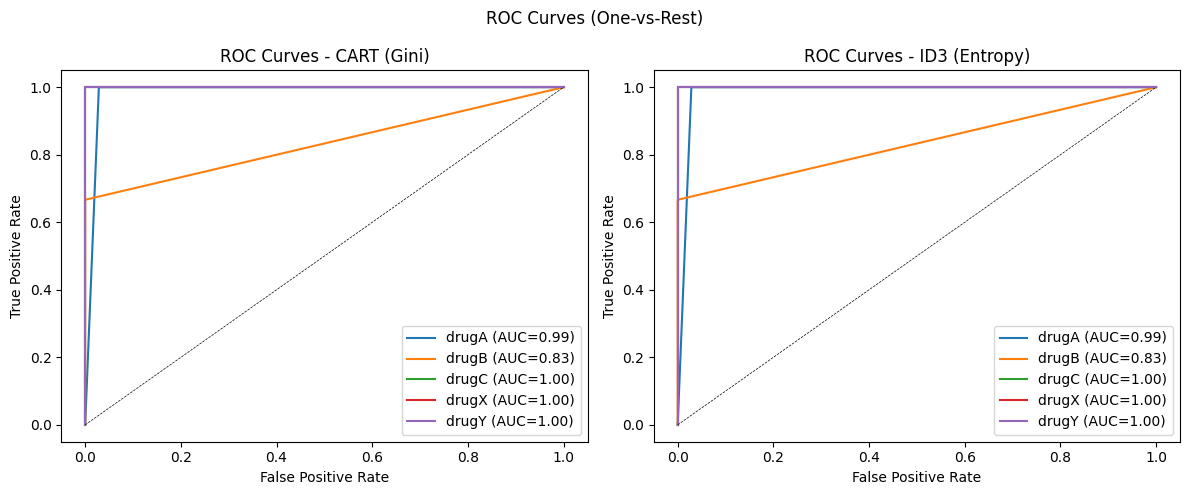

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, name in zip(axes, [best_cart, best_id3], ['CART (Gini)', 'ID3 (Entropy)']):
    y_proba = model.predict_proba(X_test)
    for i, class_name in enumerate(target_names):
        fpr, tpr, _ = roc_curve(y_test, y_proba[:, i], pos_label=i)
        # Create a binary y_true for the current class (one-vs-rest)
        y_true_binary = (y_test == i)
        auc_val = roc_auc_score(y_true_binary, y_proba[:, i])
        ax.plot(fpr, tpr, label=f'{class_name} (AUC={auc_val:.2f})')
    ax.plot([0,1], [0,1], 'k--', linewidth=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves - {name}')
    ax.legend(loc='lower right')
plt.suptitle("ROC Curves (One-vs-Rest)")
plt.tight_layout()
plt.show()

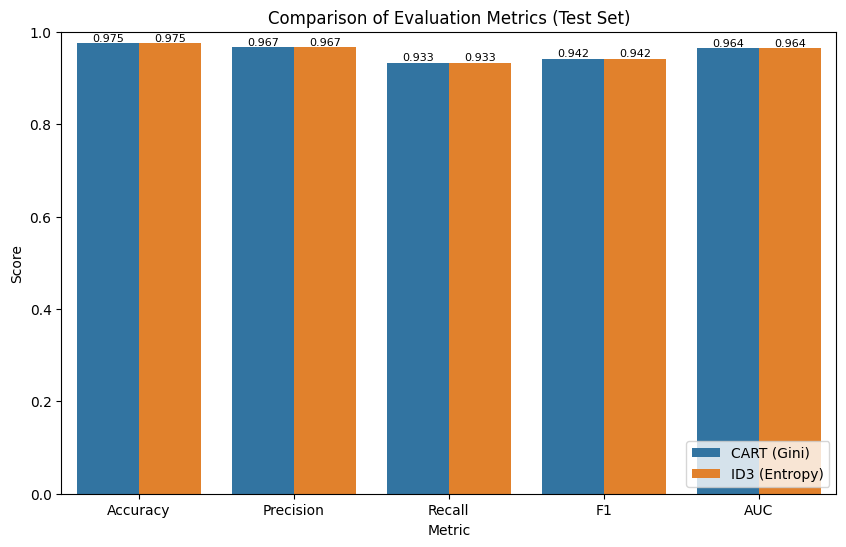

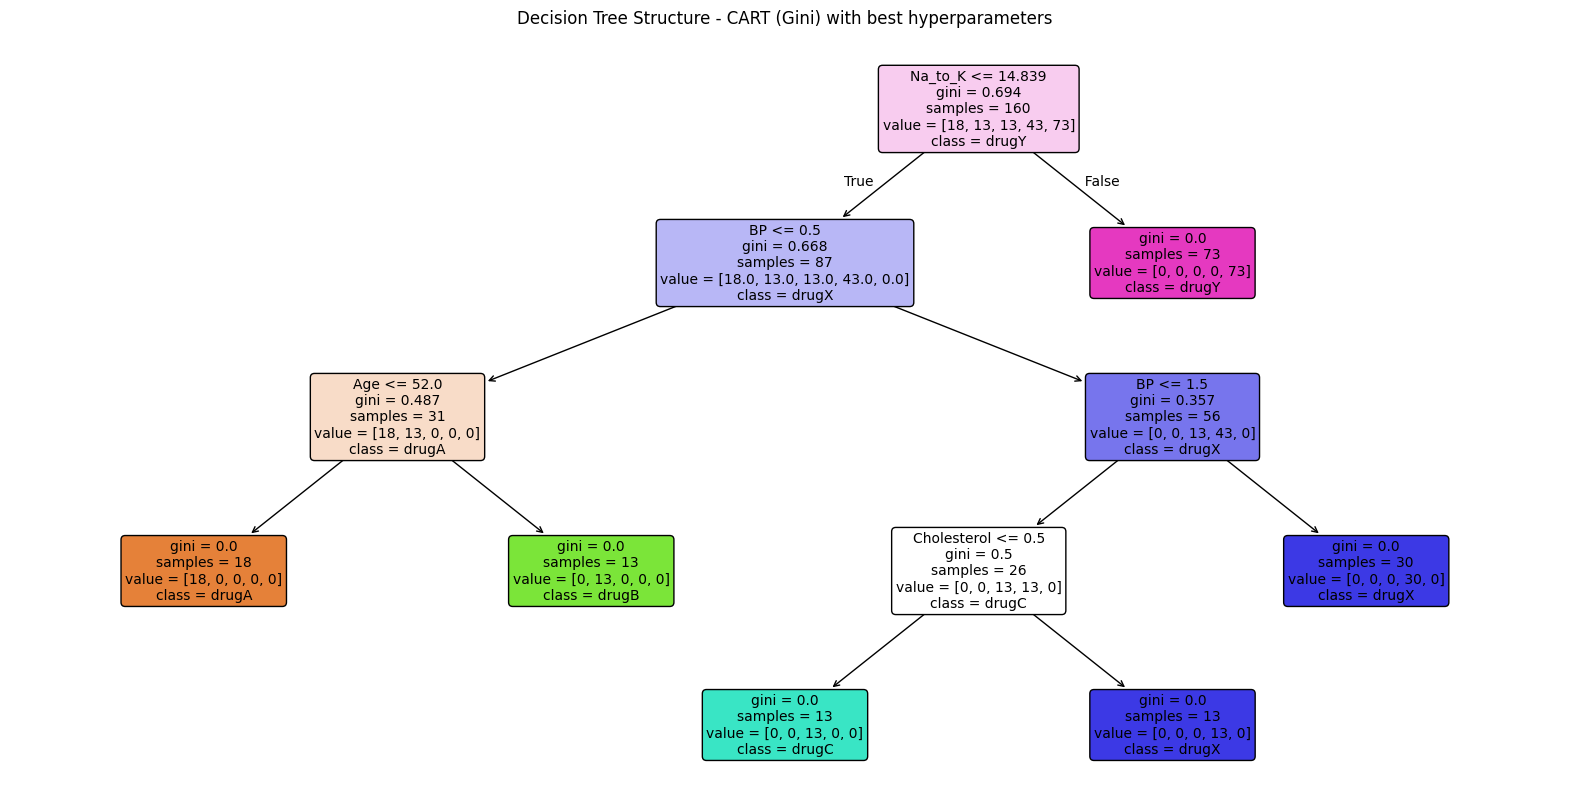

In [14]:
metrics_melt = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_melt, x='Metric', y='Score', hue='Model')
plt.title("Comparison of Evaluation Metrics (Test Set)")
plt.ylim(0, 1)
plt.legend(loc='lower right')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', fontsize=8)
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(best_cart, feature_names=X.columns, class_names=target_names,
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure - CART (Gini) with best hyperparameters")
plt.show()



In [16]:
print("\n--- Sample Predictions (first 10 test samples) ---")
sample_idx = np.arange(10)
print("Actual   :", [target_names[i] for i in y_test[sample_idx]])
print("CART pred:", [target_names[i] for i in best_cart.predict(X_test.iloc[sample_idx])])
print("ID3 pred :", [target_names[i] for i in best_id3.predict(X_test.iloc[sample_idx])])


--- Sample Predictions (first 10 test samples) ---
Actual   : ['drugC', 'drugX', 'drugA', 'drugX', 'drugY', 'drugY', 'drugY', 'drugY', 'drugY', 'drugY']
CART pred: ['drugC', 'drugX', 'drugA', 'drugX', 'drugY', 'drugY', 'drugY', 'drugY', 'drugY', 'drugY']
ID3 pred : ['drugC', 'drugX', 'drugA', 'drugX', 'drugY', 'drugY', 'drugY', 'drugY', 'drugY', 'drugY']
